# IT2011 Artificial Intelligence and Machine Learning Project
## Random Forest Classification on the UCI Letter Recognition Dataset

### Project overview
This notebook presents a supervised machine learning classification project using the **UCI Letter Recognition dataset**. The goal is to train a model that can identify capital English letters **A–Z** from numerical features extracted from letter images.

### What we do in this project
1. Load the Letter Recognition dataset from the UCI Machine Learning Repository.
2. Explore the structure of the dataset, including samples, features, target classes, missing values, duplicates, and class distribution.
3. Prepare the data for modelling using an 80:20 stratified train-test split.
4. Train a baseline Random Forest classifier.
5. Evaluate the baseline model using accuracy, precision, recall, and F1-score.
6. Tune Random Forest hyperparameters using GridSearchCV and cross-validation.
7. Check possible overfitting by comparing training and validation accuracy across different tree depths.
8. Evaluate the tuned model using detailed classification metrics, a confusion matrix, and feature importance analysis.
9. Compare the baseline and tuned models and summarize the final findings.

### Dataset summary
- **Dataset:** UCI Letter Recognition Dataset
- **Task type:** Multi-class classification
- **Target classes:** 26 capital letters, A to Z
- **Input features:** 16 numerical attributes describing letter image characteristics
- **Model used:** Random Forest Classifier

---

## 1. Environment Setup and Library Imports

In this section, the required Python libraries are installed and imported. We use:

- `pandas` and `numpy` for data handling
- `matplotlib` and `seaborn` for visualizations
- `ucimlrepo` to load the dataset directly from UCI
- `scikit-learn` for model training, tuning, and evaluation


In [25]:
# Install required library
!pip install ucimlrepo

# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Measure training/tuning time
import time

# Load dataset directly from UCI Machine Learning Repository
from ucimlrepo import fetch_ucirepo

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier


# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## 2. Loading the Dataset

The Letter Recognition dataset is loaded directly from the UCI Machine Learning Repository using dataset ID **59**. The dataset is divided into:

- `X`: input features used by the model
- `y`: target labels representing the actual letter class

The basic dataset size, number of features, and number of classes are displayed to confirm successful loading.


In [26]:
# ============================================================
# STEP 2: LOAD THE UCI LETTER RECOGNITION DATASET
# ============================================================

# Fetch dataset using UCI dataset ID 59
letter_recognition = fetch_ucirepo(id=59)

# Get input features
X = letter_recognition.data.features

# Get target variable
y = letter_recognition.data.targets.iloc[:, 0]

# Display basic information
print("Dataset loaded successfully!")
print("--------------------------------")
print("Number of samples :", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes :", y.nunique())

Dataset loaded successfully!
--------------------------------
Number of samples : 20000
Number of features: 16
Number of classes : 26


## 3. Previewing the Dataset

Before modelling, we inspect a few rows of the feature matrix and target labels. This helps us understand the data format and confirms that the target values are alphabet letters.


In [27]:
# Display the first 5 feature records
print("\nFirst 5 feature records:")
display(X.head())

# Display the first 5 target values
print("\nFirst 5 target values:")
display(y.head())


First 5 feature records:


,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10



First 5 target values:


,lettr
0,T
1,I
2,D
3,N
4,G


## 4. Exploratory Data Analysis

Exploratory Data Analysis helps us understand the dataset before training the model. Here, we check:

- dataset shape
- feature names
- target classes
- missing values
- duplicate feature rows

This step is important because data quality directly affects model performance.


In [28]:
# ============================================================
# STEP 3: EXPLORATORY DATA ANALYSIS
# ============================================================

print("DATASET INFORMATION")
print("-------------------")

# Dataset dimensions
print("Shape:", X.shape)

# Feature names
print("\nFeature names:")
print(list(X.columns))

# Target classes
print("\nTarget classes:")
print(sorted(y.unique()))

# Check missing values
print("\nTotal missing values:")
print(X.isnull().sum().sum())

# Check duplicate feature rows
print("\nDuplicate feature rows:")
print(X.duplicated().sum())

DATASET INFORMATION
-------------------
Shape: (20000, 16)

Feature names:
['x-box', 'y-box', 'width', 'high', 'onpix', 'x-bar', 'y-bar', 'x2bar', 'y2bar', 'xybar', 'x2ybr', 'xy2br', 'x-ege', 'xegvy', 'y-ege', 'yegvx']

Target classes:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Total missing values:
0

Duplicate feature rows:
1332


### 4.1 Statistical Summary

The statistical summary shows the range, mean, standard deviation, and quartiles for each numerical feature. Since all features are numerical, this helps us understand the distribution and scale of the values.


In [29]:
# Display statistical summary of numerical features
print("\nSTATISTICAL SUMMARY")
print("-------------------")

display(X.describe())


STATISTICAL SUMMARY
-------------------


,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,4.023550,7.035500,5.121850,5.37245,3.505850,6.897600,7.500450,4.628600,5.178650,8.282050,6.45400,7.929000,3.046100,8.338850,3.691750,7.80120
std,1.913212,3.304555,2.014573,2.26139,2.190458,2.026035,2.325354,2.699968,2.380823,2.488475,2.63107,2.080619,2.332541,1.546722,2.567073,1.61747
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,3.000000,5.000000,4.000000,4.00000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,5.00000,7.000000,1.000000,8.000000,2.000000,7.00000
50%,4.000000,7.000000,5.000000,6.00000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,6.00000,8.000000,3.000000,8.000000,3.000000,8.00000
75%,5.000000,9.000000,6.000000,7.00000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,8.00000,9.000000,4.000000,9.000000,5.000000,9.00000
max,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.00000


### 4.2 Class Distribution

We count how many samples belong to each letter class. A balanced class distribution is useful because it prevents the model from being biased toward only a few frequent classes.


In [30]:
# Count samples in each letter class
class_counts = y.value_counts().sort_index()

print("\nCLASS DISTRIBUTION")
print("------------------")

print(class_counts)


CLASS DISTRIBUTION
------------------
lettr
A    789
B    766
C    736
D    805
E    768
F    775
G    773
H    734
I    755
J    747
K    739
L    761
M    792
N    783
O    753
P    803
Q    783
R    758
S    748
T    796
U    813
V    764
W    752
X    787
Y    786
Z    734
Name: count, dtype: int64


### 4.3 Visualizing Class Distribution

The bar chart gives a clearer visual view of how samples are distributed across the 26 letters.


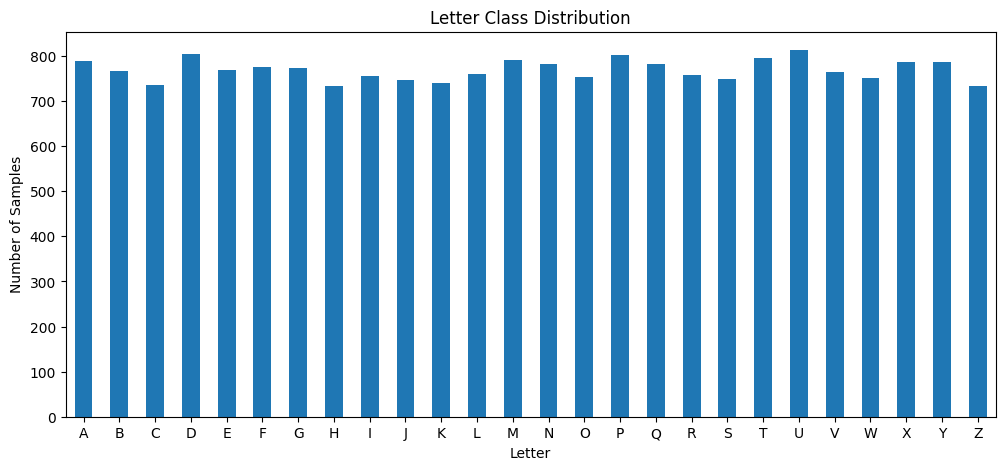

In [31]:
# Plot the number of samples for each letter
plt.figure(figsize=(12, 5))

class_counts.plot(kind='bar')

plt.title("Letter Class Distribution")
plt.xlabel("Letter")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.show()

## 5. Data Preprocessing

The dataset is checked for missing values and duplicate feature rows. No missing values were found, so no imputation was required. Duplicate feature rows are noted, but they are not removed here because identical feature patterns may still correspond to valid examples in this dataset.


In [32]:
# ============================================================
# STEP 4: DATA PREPROCESSING
# ============================================================

# Check for missing values
missing_values = X.isnull().sum().sum()

if missing_values == 0:
    print("No missing values found.")
else:
    print("Missing values found:", missing_values)

# Check for duplicate rows
duplicates = X.duplicated().sum()

print("Duplicate feature rows:", duplicates)

No missing values found.
Duplicate feature rows: 1332


## 6. Train-Test Split

The dataset is split into training and testing sets:

- **80% training data** for fitting the model
- **20% testing data** for final evaluation

A stratified split is used so that all letter classes remain proportionally represented in both sets.


In [33]:
# ============================================================
# STEP 5: TRAIN-TEST SPLIT
# ============================================================

# Split the dataset into:
# 80% training data
# 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("TRAIN-TEST SPLIT")
print("----------------")
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

TRAIN-TEST SPLIT
----------------
Training samples: 16000
Testing samples : 4000


## 7. Baseline Random Forest Model

A baseline Random Forest classifier is trained using default-style settings with 100 decision trees. This gives us an initial performance score before hyperparameter tuning.

Random Forest is suitable here because it can handle numerical features well, reduce overfitting compared with a single decision tree, and perform strongly on multi-class classification tasks.


In [34]:
# ============================================================
# STEP 6: BASELINE RANDOM FOREST MODEL
# ============================================================

# Create the baseline Random Forest classifier
baseline_rf = RandomForestClassifier(
    n_estimators=100,   # Number of decision trees
    random_state=42,    # Makes results reproducible
    n_jobs=-1           # Use all available CPU cores
)

# Record training start time
start_time = time.time()

# Train the model
baseline_rf.fit(
    X_train,
    y_train
)

# Calculate training time
training_time = time.time() - start_time

print("Baseline Random Forest trained successfully!")
print(
    "Training time:",
    round(training_time, 2),
    "seconds"
)

Baseline Random Forest trained successfully!
Training time: 2.76 seconds


## 8. Baseline Model Evaluation

The baseline model is evaluated using four common classification metrics:

- **Accuracy:** overall percentage of correct predictions
- **Precision:** how many predicted labels were correct
- **Recall:** how many actual labels were correctly identified
- **F1-score:** balanced measure of precision and recall

Weighted averaging is used because this is a multi-class classification problem.


In [35]:
# ============================================================
# STEP 7: BASELINE MODEL EVALUATION
# ============================================================

# Predict letters using the test dataset
y_pred_baseline = baseline_rf.predict(X_test)

# Calculate evaluation metrics

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

baseline_precision = precision_score(
    y_test,
    y_pred_baseline,
    average='weighted'
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline,
    average='weighted'
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    average='weighted'
)

# Display results
print("BASELINE RANDOM FOREST RESULTS")
print("--------------------------------")

print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1 Score :", round(baseline_f1, 4))

BASELINE RANDOM FOREST RESULTS
--------------------------------
Accuracy : 0.9675
Precision: 0.9678
Recall   : 0.9675
F1 Score : 0.9675


## 9. Hyperparameter Tuning

Hyperparameter tuning is used to improve model performance and reduce overfitting. We use `GridSearchCV` to test different Random Forest settings such as:

- number of trees
- maximum tree depth
- minimum samples required for splitting
- minimum samples per leaf
- number of features considered at each split

Cross-validation helps select a model that performs well on unseen data, not only on the training set.


In [36]:
# ============================================================
# STEP 8: OVERFITTING MITIGATION & HYPERPARAMETER TUNING
# ============================================================

# Create Random Forest model for tuning
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

### 9.1 Defining the Hyperparameter Grid

The parameter grid contains different combinations of Random Forest settings. GridSearchCV will train and compare models for every combination in this grid.


In [37]:
# Define different Random Forest configurations

param_grid = {

    # Number of decision trees
    'n_estimators': [100, 200],

    # Maximum depth of each tree
    'max_depth': [10, 20, 30],

    # Minimum samples required to split a node
    'min_samples_split': [2, 5, 10],

    # Minimum samples required in a leaf
    'min_samples_leaf': [1, 2, 4],

    # Number of features considered at each split
    'max_features': ['sqrt', 'log2']
}

print("Hyperparameter grid created.")

Hyperparameter grid created.


### 9.2 Creating GridSearchCV

`cv=5` means the training data is split into five folds for cross-validation. This provides a more reliable estimate of model performance than using only one validation split.


In [38]:
# Create GridSearchCV
# cv=5 means 5-fold cross-validation

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

### 9.3 Running Hyperparameter Tuning

This step can take several minutes because many parameter combinations are trained and evaluated. In this notebook, 108 parameter combinations are tested using 5-fold cross-validation.


In [39]:
# Start timer
start_time = time.time()

# Train all parameter combinations
grid_search.fit(
    X_train,
    y_train
)

# Calculate tuning time
tuning_time = time.time() - start_time

print("\nHyperparameter tuning completed!")

print(
    "Tuning time:",
    round(tuning_time, 2),
    "seconds"
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Hyperparameter tuning completed!
Tuning time: 999.5 seconds


### 9.4 Best Parameters

After tuning, the best parameter combination and the best cross-validation accuracy are displayed. These values are used to select the final tuned Random Forest model.


In [40]:
# Display the best parameter combination

print("\nBEST PARAMETERS")
print("----------------")

print(grid_search.best_params_)

print(
    "\nBest Cross-Validation Accuracy:",
    round(grid_search.best_score_, 4)
)


BEST PARAMETERS
----------------
{'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation Accuracy: 0.9554


## 10. Overfitting Analysis

To check overfitting, we compare training accuracy and validation accuracy at different tree depths.

- If training accuracy is very high but validation accuracy is much lower, the model may be overfitting.
- If both scores are low, the model may be underfitting.
- A good model should maintain strong validation performance while avoiding unnecessary complexity.


Max Depth: 5 | Train Accuracy: 0.6549 | Validation Accuracy: 0.6465
Max Depth: 10 | Train Accuracy: 0.8931 | Validation Accuracy: 0.8595
Max Depth: 15 | Train Accuracy: 0.9920 | Validation Accuracy: 0.9557
Max Depth: 20 | Train Accuracy: 0.9999 | Validation Accuracy: 0.9650
Max Depth: 25 | Train Accuracy: 1.0000 | Validation Accuracy: 0.9677
Max Depth: 30 | Train Accuracy: 1.0000 | Validation Accuracy: 0.9663
Max Depth: None | Train Accuracy: 1.0000 | Validation Accuracy: 0.9675


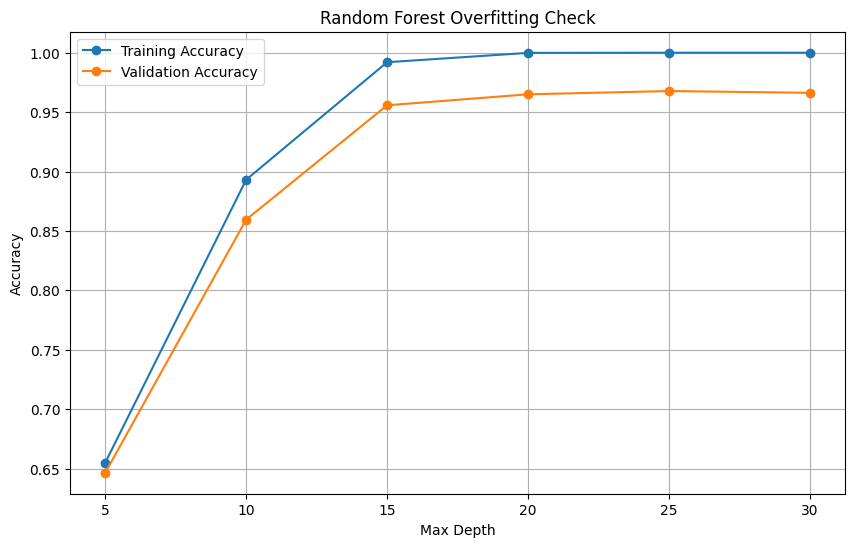

In [50]:


# Different tree depths to test
depths = [5, 10, 15, 20, 25, 30, None]

train_accuracies = []
val_accuracies = []

for depth in depths:

    # Create Random Forest model
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    # Train the model
    rf.fit(X_train, y_train)

    # Training predictions
    train_pred = rf.predict(X_train)

    # Validation/Test predictions
    val_pred = rf.predict(X_test)

    # Calculate accuracies
    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_test, val_pred)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Max Depth: {depth} | "
        f"Train Accuracy: {train_acc:.4f} | "
        f"Validation Accuracy: {val_acc:.4f}"
    )

# ==========================================
# PLOT OVERFITTING CHECK
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    train_accuracies,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    depths,
    val_accuracies,
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Random Forest Overfitting Check")
plt.legend()
plt.grid(True)

plt.show()

## 11. Tuned Random Forest Evaluation

The best model selected by GridSearchCV is evaluated on the test dataset. This gives the final performance of the tuned Random Forest model.


In [41]:
# ============================================================
# STEP 9: BEST RANDOM FOREST MODEL EVALUATION
# ============================================================

# Get the best model found by GridSearchCV
best_rf = grid_search.best_estimator_

# Predict the test dataset
y_pred_best = best_rf.predict(X_test)

# Calculate metrics

best_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

best_precision = precision_score(
    y_test,
    y_pred_best,
    average='weighted'
)

best_recall = recall_score(
    y_test,
    y_pred_best,
    average='weighted'
)

best_f1 = f1_score(
    y_test,
    y_pred_best,
    average='weighted'
)

# Display results

print("BEST RANDOM FOREST RESULTS")
print("--------------------------")

print("Accuracy :", round(best_accuracy, 4))
print("Precision:", round(best_precision, 4))
print("Recall   :", round(best_recall, 4))
print("F1 Score :", round(best_f1, 4))

BEST RANDOM FOREST RESULTS
--------------------------
Accuracy : 0.9685
Precision: 0.9688
Recall   : 0.9685
F1 Score : 0.9685


### 11.1 Classification Report

The classification report shows precision, recall, and F1-score for every letter class. This helps identify which letters are classified very well and which letters are more difficult for the model.


In [42]:
# Detailed evaluation for every letter

print("\nCLASSIFICATION REPORT")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred_best
    )
)


CLASSIFICATION REPORT
---------------------
              precision    recall  f1-score   support

           A       0.99      0.99      0.99       158
           B       0.92      0.97      0.94       153
           C       0.97      0.97      0.97       147
           D       0.92      0.97      0.94       161
           E       0.97      0.96      0.96       154
           F       0.94      0.95      0.95       155
           G       0.97      0.96      0.96       155
           H       0.94      0.88      0.91       147
           I       0.97      0.94      0.96       151
           J       0.97      0.97      0.97       149
           K       0.94      0.97      0.96       148
           L       1.00      0.99      0.99       152
           M       0.99      0.99      0.99       158
           N       0.97      0.96      0.96       157
           O       0.95      0.97      0.96       150
           P       0.98      0.96      0.97       161
           Q       0.95      0.97   

## 12. Confusion Matrix

The confusion matrix shows how often each actual letter was predicted as each possible letter. It is useful for identifying specific misclassification patterns between similar-looking letters.


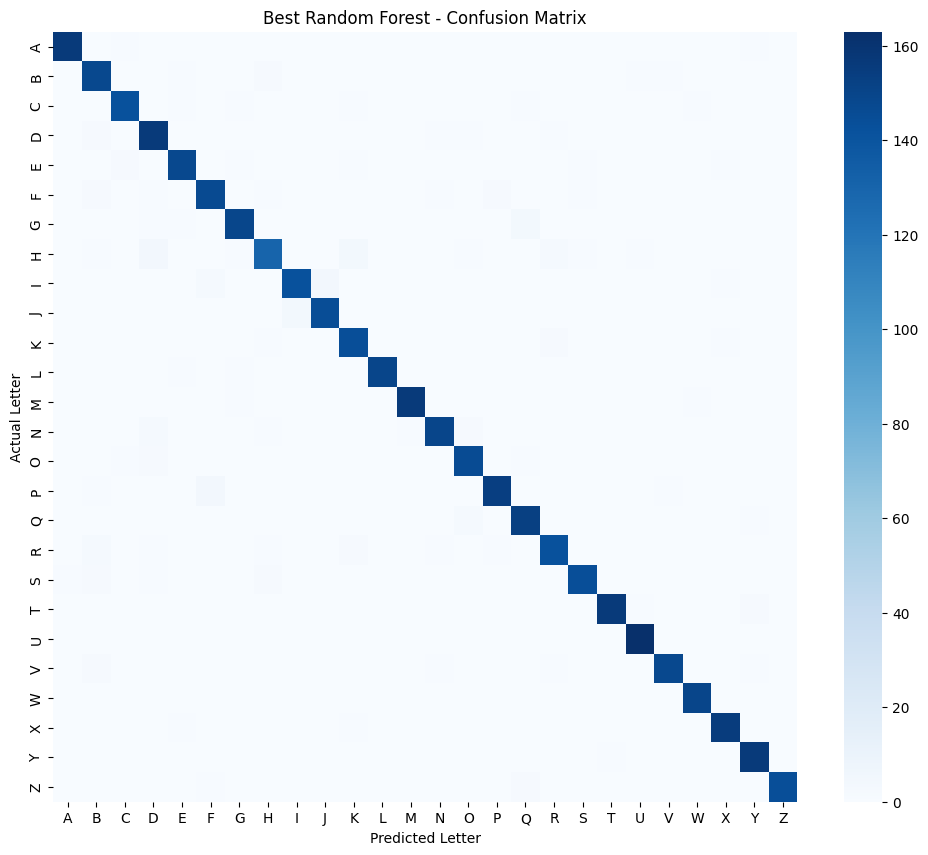

In [43]:
# ============================================================
# STEP 10: VISUALIZATION & FINAL ANALYSIS
# ============================================================

# Get all letter classes
letters = sorted(y.unique())

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_best
)

# Plot confusion matrix
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    xticklabels=letters,
    yticklabels=letters
)

plt.title(
    "Best Random Forest - Confusion Matrix"
)

plt.xlabel("Predicted Letter")
plt.ylabel("Actual Letter")

plt.show()

## 13. Feature Importance

Random Forest can estimate how important each feature was when making predictions. Higher feature importance means the feature contributed more strongly to the model's decision-making process.


In [44]:
# Calculate feature importance

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
        best_rf.feature_importances_

})

# Sort from highest to lowest importance

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("FEATURE IMPORTANCE")
print("------------------")

display(feature_importance)

FEATURE IMPORTANCE
------------------


,Feature,Importance
12,x-ege,0.117816
14,y-ege,0.101244
8,y2bar,0.091971
7,x2bar,0.084735
10,x2ybr,0.082616
11,xy2br,0.082589
13,xegvy,0.075560
9,xybar,0.072273
6,y-bar,0.068246
15,yegvx,0.054202


### 13.1 Visualizing Feature Importance

The bar chart ranks features from most important to least important. This makes it easier to explain which extracted letter characteristics influenced the model most.


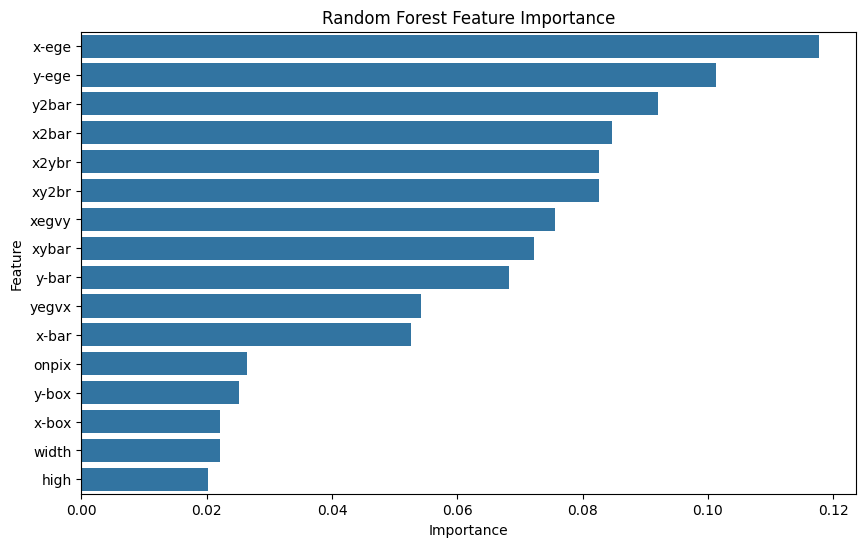

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 14. Grid Search Results Table

This table displays the tested hyperparameter combinations and their cross-validation scores. It provides transparency about how the final model configuration was selected.


In [46]:
# Get all GridSearchCV results

results = pd.DataFrame(
    grid_search.cv_results_
)

# Select useful columns

results_table = results[
    [
        'param_n_estimators',
        'param_max_depth',
        'param_min_samples_split',
        'param_min_samples_leaf',
        'param_max_features',
        'mean_test_score',
        'std_test_score',
        'rank_test_score'
    ]
].copy()

# Sort by best rank

results_table = results_table.sort_values(
    'rank_test_score'
)

display(results_table)

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,mean_test_score,std_test_score,rank_test_score
91,200,30,2,1,log2,0.955438,0.001982,1
73,200,30,2,1,sqrt,0.955438,0.001982,1
55,200,20,2,1,log2,0.954125,0.002698,3
37,200,20,2,1,sqrt,0.954125,0.002698,3
72,100,30,2,1,sqrt,0.953875,0.002757,5
...,...,...,...,...,...,...,...,...
14,100,10,5,4,sqrt,0.852875,0.006627,101
28,100,10,10,2,log2,0.852125,0.007755,105
10,100,10,10,2,sqrt,0.852125,0.007755,105
34,100,10,10,4,log2,0.850125,0.009663,107


## 15. Baseline vs Tuned Model Comparison

The final comparison table summarizes the performance difference between the baseline Random Forest and the tuned Random Forest model.


In [47]:
# Create final comparison table

final_comparison = pd.DataFrame({

    'Model': [
        'Baseline Random Forest',
        'Tuned Random Forest'
    ],

    'Accuracy': [
        baseline_accuracy,
        best_accuracy
    ],

    'Precision': [
        baseline_precision,
        best_precision
    ],

    'Recall': [
        baseline_recall,
        best_recall
    ],

    'F1 Score': [
        baseline_f1,
        best_f1
    ]
})

display(final_comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Random Forest,0.9675,0.967845,0.9675,0.967476
1,Tuned Random Forest,0.9685,0.968801,0.9685,0.968496


### 15.1 Visual Model Comparison

The bar chart visually compares accuracy, precision, recall, and F1-score for the baseline and tuned models.


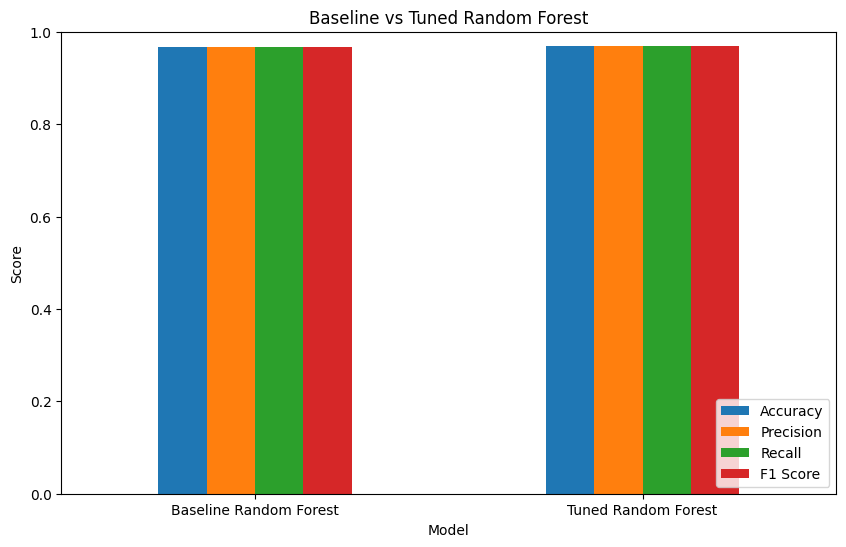

In [48]:
# Plot baseline vs tuned model performance

final_comparison.set_index(
    'Model'
)[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title(
    "Baseline vs Tuned Random Forest"
)

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    loc='lower right'
)

plt.show()

## 16. Final Conclusion

The Random Forest classifier achieved strong performance on the UCI Letter Recognition dataset. The baseline model already performed well, reaching approximately **96.75% accuracy**. After hyperparameter tuning, the final model improved slightly to approximately **96.85% accuracy**.

The results show that Random Forest is effective for this multi-class letter classification problem. The tuned model provides a small improvement over the baseline model, while the overfitting analysis shows that very deep trees can perfectly fit the training data but may not always provide meaningful validation improvement.

### Key findings
- The dataset contains **20,000 samples**, **16 numerical features**, and **26 target classes**.
- There were **no missing values**, so no missing-value treatment was required.
- The class distribution is fairly balanced across letters.
- The tuned Random Forest model achieved the best final test performance.
- Feature importance analysis showed which numerical attributes contributed most to classification decisions.

### Limitations
- The project uses only the provided numerical features, not raw letter images.
- GridSearchCV improves the model but increases training time significantly.
- The accuracy improvement after tuning is small, so simpler settings may be preferred if speed is important.

### Future improvements
- Try additional algorithms such as Support Vector Machines, Gradient Boosting, or Neural Networks.
- Use RandomizedSearchCV to reduce tuning time.
- Analyze commonly confused letters in more detail using the confusion matrix.
- Test model performance with different train-test split ratios.
